In [1]:
import warnings
import os
import time
import subprocess
import csv
from pathlib import Path
from math import gcd
from itertools import cycle
from collections import Counter
from functools import partial, lru_cache
from typing import List, Tuple, Optional, Dict, Any
import concurrent.futures
import tempfile
import numpy as np
from scipy import constants, spatial
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import ipywidgets as widgets
from IPython.display import display

# Scientific computing imports
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.io.cif import CifWriter
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from ase import io, Atoms
from io import StringIO
from ase.neighborlist import neighbor_list
from ase.io import read
from ase.data import atomic_masses
from ase.data import atomic_numbers
from ase.geometry import cellpar_to_cell
from ase.geometry import distance

# Configure warnings
warnings.filterwarnings("ignore", message="WARNING - doing cell minimisation without finite basis correction:")
warnings.filterwarnings("ignore", module="ase")

# Enable interactive plotting
%matplotlib widget

# --- Constants ---
DENSITY_CONVERSION_FACTOR = 1/(constants.N_A * 1e-24)  # AMU/A³ → g/cm³
meV_CONVERSION_FACTOR = 1000  # eV to meV
LOW_ENERGY_THRESHOLD = 30.0  # meV/atom
MAX_WORKERS = 8

# --- Configuration ---
class Config:
    """Configuration class for analysis parameters"""
    def __init__(self):
        self.relative_energies_on = True
        self.apply_cyanurate_filter = False
        self.apply_keep_octahedral = False
        self.apply_keep_tetrahedral = False
        self.apply_InN6_InS6_structure = False
        self.apply_keep_layer = False
        self.apply_keep_chain = False
        self.do_low_energy_file = False
        self.vesta_path = r"C:\\VESTA-win64\\VESTA-win64\\VESTA.exe"
        self.convex_hull = False
        self.filter_folder = True
        self.print_results = True
        self.export_csv_summary = False
        self.csv_output_name = "file_summary.csv"

class RESAnalyzer:


In [2]:
# Add filtered-file caching to RESAnalyzer
import shutil


class RESAnalyzer(RESAnalyzer):
    def save_filtered_files(self, folder: Path, file_names: np.ndarray, output_suffix: str = "_filtered") -> Path:
        """Copy filter-passing files to a refreshed sibling cache folder."""
        source_folder = Path(folder)
        output_folder = source_folder.parent / f"{source_folder.name}{output_suffix}"
        output_folder.mkdir(parents=True, exist_ok=True)

        for cached_file in output_folder.iterdir():
            if cached_file.is_file() and cached_file.suffix.lower() in {".res", ".cif"}:
                cached_file.unlink()

        copied = 0
        for file_path in file_names:
            source_file = Path(file_path)
            shutil.copy2(source_file, output_folder / source_file.name)
            copied += 1

            for cif_file in (
                source_file.with_suffix(".cif"),
                source_file.with_name(source_file.stem + "-out.cif"),
            ):
                if cif_file.exists():
                    shutil.copy2(cif_file, output_folder / cif_file.name)

        print(f"Saved {copied} filter-passing files to: {output_folder}")
        return output_folder

    def process_folder(self, folder: Path):
        """Process a folder and cache the files that survive its active filters."""
        result = super().process_folder(folder)

        active_filters = any([
            self.config.apply_cyanurate_filter,
            self.config.apply_keep_octahedral,
            self.config.apply_keep_tetrahedral,
            self.config.apply_keep_layer,
            self.config.apply_keep_chain,
            self.config.apply_InN6_InS6_structure,
        ])
        if active_filters and result and self.config.filter_folder:
            self.save_filtered_files(folder, result[0])

        return result

NameError: name 'RESAnalyzer' is not defined

In [ ]:
def _export_file_summary_csv(self, folder_path: str | Path, output_name: Optional[str] = None) -> Optional[Path]:
    """Export a CSV with file name, energy, density, stoichiometry, filter flags, and low-energy status."""
    if not getattr(self.config, "export_csv_summary", False):
        return None

    folder = Path(folder_path)
    if not folder.exists():
        raise FileNotFoundError(f"Folder does not exist: {folder}")

    output_path = folder / (output_name or getattr(self.config, "csv_output_name", "file_summary.csv"))
    records = []

    low_energy_dir = folder
    if folder.name != "low_energies_from_plot":
        low_energy_dir = folder.parent / "low_energies_from_plot"

    for file_path in sorted(folder.iterdir()):
        if not file_path.is_file() or file_path.suffix.lower() not in {'.res', '.castep'}:
            continue

        try:
            result, _ = self.process_single_file(file_path)
            if result is None:
                continue
            _, density, energy_per_atom, formula_units, stoichiometry = result

            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()

            tmp = tempfile.NamedTemporaryFile(mode='w+', suffix='.res', delete=False)
            try:
                tmp.write(content)
                tmp.close()
                atoms = read(tmp.name, format='res')
                if isinstance(atoms, list):
                    atoms = atoms[0]
            finally:
                os.unlink(tmp.name)

            c_filter = self._has_cyanurate_structure(atoms, self._get_cached_neighbors(atoms, 2.1))
            o_filter = self._has_octahedral_indium(atoms, self._get_cached_neighbors(atoms, 3.0))
            in6_filter = self._has_InN6_InS6_structure(atoms, self._get_cached_neighbors(atoms, 3.0))
            in_low_energy_folder = (low_energy_dir / file_path.name).exists()

            records.append({
                'file_name': file_path.name,
                'energy_per_atom': energy_per_atom,
                'density': density,
                'formula_units': formula_units,
                'stoichiometry': stoichiometry,
                'has_cyanurate_structure': bool(c_filter),
                'has_octahedral_indium': bool(o_filter),
                'has_InN6_InS6_structure': bool(in6_filter),
                'in_low_energy_folder': bool(in_low_energy_folder),
                'filter_flags': [bool(c_filter), bool(o_filter), bool(in6_filter)],
            })
        except Exception:
            continue

    with output_path.open('w', newline='', encoding='utf-8') as csv_file:
        writer = csv.DictWriter(
            csv_file,
            fieldnames=[
                'file_name',
                'energy_per_atom',
                'density',
                'formula_units',
                'stoichiometry',
                'has_cyanurate_structure',
                'has_octahedral_indium',
                'has_InN6_InS6_structure',
                'in_low_energy_folder',
                'filter_flags',
            ]
        )
        writer.writeheader()
        for row in records:
            writer.writerow({
                'file_name': row['file_name'],
                'energy_per_atom': row['energy_per_atom'],
                'density': row['density'],
                'formula_units': row['formula_units'],
                'stoichiometry': row['stoichiometry'],
                'has_cyanurate_structure': row['has_cyanurate_structure'],
                'has_octahedral_indium': row['has_octahedral_indium'],
                'has_InN6_InS6_structure': row['has_InN6_InS6_structure'],
                'in_low_energy_folder': row['in_low_energy_folder'],
                'filter_flags': row['filter_flags'],
            })

    return output_path


RESAnalyzer.export_file_summary_csv = _export_file_summary_csv


In [20]:
config = Config()
config.export_csv_summary = True
config.csv_output_name = "DFT-MDB_all_structures_summary.csv"

analyzer = RESAnalyzer(config)
csv_path = analyzer.export_file_summary_csv(r"C:\Users\Miles\Documents\morris research\computing\All ress\DFT MDB\low energy")

🚀 Starting optimized analysis...
Found 5987 .res files
Processing batch 1/6


Processing batch:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing batch 2/6


Processing batch:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing batch 3/6


...

Processing batch:   0%|          | 0/1000 [00:00<?, ?it/s]

Processing batch 6/6


Processing batch:   0%|          | 0/987 [00:00<?, ?it/s]

['TITL', 'InNCS3_218_P-43n_ne3n7hZE', 'edit', '0.042', '1933.919999', '-31339.4055', '0', '0', '80', '(P-43n)', 'n', '-', '1']
Successfully processed: 5987 files
Failed to process: 0 files

✅ Processed 5987 files
⏱️ Total time: 12.59 seconds
⏱️ Average time per file: 0.017 seconds
⏱️ Files per second: 475.57
🎉 Total analysis completed in 14.370979070663452 seconds


Text(value='', description='Search:', placeholder='Enter filename or stoichiometry')

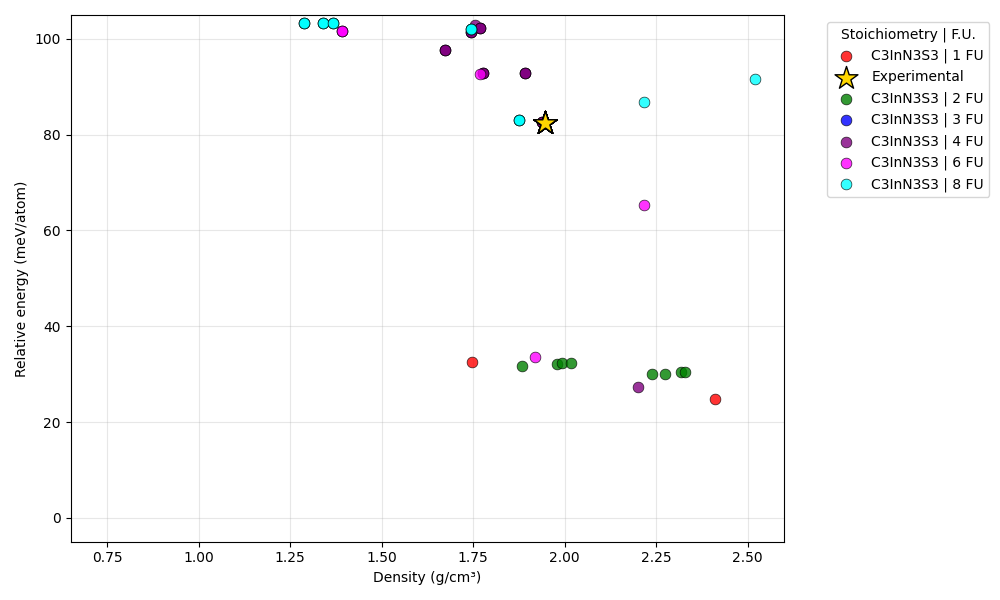

In [ ]:
"""Main execution function with optimizations"""
# Configuration
config = Config()
config.relative_energies_on = True
config.convex_hull = False
config.apply_cyanurate_filter = False
config.apply_keep_octahedral = False
config.apply_InN6_InS6_structure = False
config.apply_keep_chain = False
config.do_low_energy_file = False
config.filter_folder= False
# Set folder path this needs to be changed to your folder path
#C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered
#C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3\low energy files
folder = Path(r"C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5" )
analyzer = RESAnalyzer(config)

# try:
print("🚀 Starting optimized analysis...")
start_time = time.time()

results = analyzer.process_folder(folder)

total_time = time.time() - start_time
print(f"🎉 Total analysis completed in {total_time} seconds")

if results:
    file_names, densities, energies, formula_units, stoichiometries = results
    
    # Create interactive plot
    analyzer.create_interactive_plot(
        file_names, energies, densities, formula_units, stoichiometries
    )
    
    
else:
    print("No data to plot.")
        


hello
🚀 Starting optimized analysis...
Found 58 .res files
Pre-filtering files...


Filtering files:   0%|          | 0/58 [00:00<?, ?it/s]

Filtered 58 -> 58 files in 1.79s
Processing batch 1/1


Processing batch:   0%|          | 0/58 [00:00<?, ?it/s]

Successfully processed: 58 files
Failed to process: 0 files

✅ Processed 58 files
⏱️ Total time: 0.37 seconds
⏱️ Average time per file: 0.044 seconds
⏱️ Files per second: 156.73
Found 52 .res files
Pre-filtering files...


Filtering files:   0%|          | 0/52 [00:00<?, ?it/s]

Filtered 52 -> 52 files in 0.92s
Processing batch 1/1


Processing batch:   0%|          | 0/52 [00:00<?, ?it/s]

Successfully processed: 52 files
Failed to process: 0 files

✅ Processed 52 files
⏱️ Total time: 0.26 seconds
⏱️ Average time per file: 0.038 seconds
⏱️ Files per second: 196.52
🎉 Total analysis completed in 3.4221932888031006 seconds

Arrow Drawing Debug Info:
Dataset 1: 58 unique files
Dataset 2: 52 unique files
Matching files: 52

Sample matching files (first 5):
  InNCS3_176_P63_m_yE0HUeoU.res: (1.48, 27.27) -> (1.40, 31.27)
  InNCS3_193_P63_mcm_cMmcZzJ8.res: (1.55, 29.03) -> (1.39, 31.39)
  InNCS3_205_Pa-3_NnO0b3Fm.res: (2.37, 96.58) -> (2.39, 99.81)
  InNCS3_162_P-31m_lbKwk0L2.res: (0.72, 110.13) -> (0.66, 116.14)
  InNCS3_163_P-31c_JUFFzzOB.res: (1.26, 29.19) -> (1.28, 33.91)
Arrows drawn: 51


Text(value='', description='Search:', placeholder='Enter filename or stoichiometry')

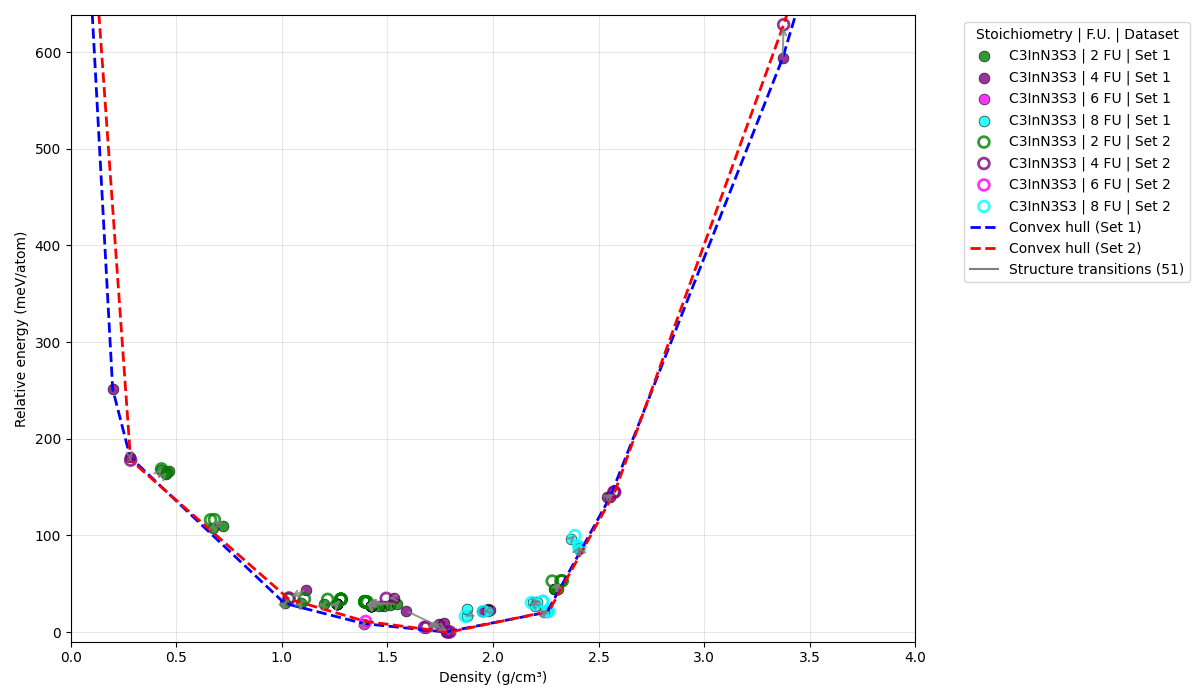

In [3]:
"""Makes the plot to compare two different folders of res files"""
# Configuration
config = Config()
config.relative_energies_on = True
config.apply_cyanurate_filter = True
config.apply_keep_octahedral = False
config.apply_keep_tetrahedral = False
config.apply_keep_layer = False
config.apply_keep_chain = False
config.do_low_energy_file = False
print("hello")
# Set folder path
folder_1 = Path(r"C:\Users\Miles\Documents\Summer research\computing\Convex_hull\Low_energies")
folder_2 = Path(r"C:\Users\Miles\Documents\Summer research\computing\Convex_hull\Low_energy_post_DFT")
#Path(r"C:\Users\Miles\Documents\Summer research\computing\Big energy density graph\low_energies_from_plot")
#Path(r"C:\Users\Miles\Documents\Summer research\computing\Big energy density graph\In[NCS]3")
#Path(r"C:\Users\Miles\Documents\Summer research\computing\Convex_hull\low_energies")
# Create analyzer and process data
analyzer = RESAnalyzer(config)

# try:
print("🚀 Starting optimized analysis...")
start_time = time.time()
# Full_results= analyzer.process_multiple_folders(folders=[folder_1, folder_2])
# results_1 = Full_results.get(folder_1.name, None)
# results_2 = Full_results.get(folder_2.name, None)
results_1 = analyzer.process_folder(folder_1)
results_2 = analyzer.process_folder(folder_2)
total_time = time.time() - start_time
print(f"🎉 Total analysis completed in {total_time} seconds")

if results_1 and results_2:
    file_names_1, densities_1, energies_1, formula_units_1, stoichiometries_1 = results_1
    file_names_2, densities_2, energies_2, formula_units_2, stoichiometries_2 = results_2

    # Create interactive plot
    analyzer.create_comparison_plot(
        file_names_1, energies_1, densities_1, formula_units_1, stoichiometries_1,
        file_names_2, energies_2, densities_2, formula_units_2, stoichiometries_2
    )
else:
    print("No data to plot.")



Found 61 .res files
Processing batch 1/1


Processing batch:   0%|          | 0/61 [00:00<?, ?it/s]

Successfully processed: 61 files
Failed to process: 0 files

✅ Processed 61 files
⏱️ Total time: 0.12 seconds
⏱️ Average time per file: 0.013 seconds
⏱️ Files per second: 515.06
Found 61 .res files
Processing batch 1/1


Processing batch:   0%|          | 0/61 [00:00<?, ?it/s]

Successfully processed: 61 files
Failed to process: 0 files

✅ Processed 61 files
⏱️ Total time: 0.11 seconds
⏱️ Average time per file: 0.011 seconds
⏱️ Files per second: 566.23


Text(value='', description='Search:', placeholder='Enter filename or stoichiometry')

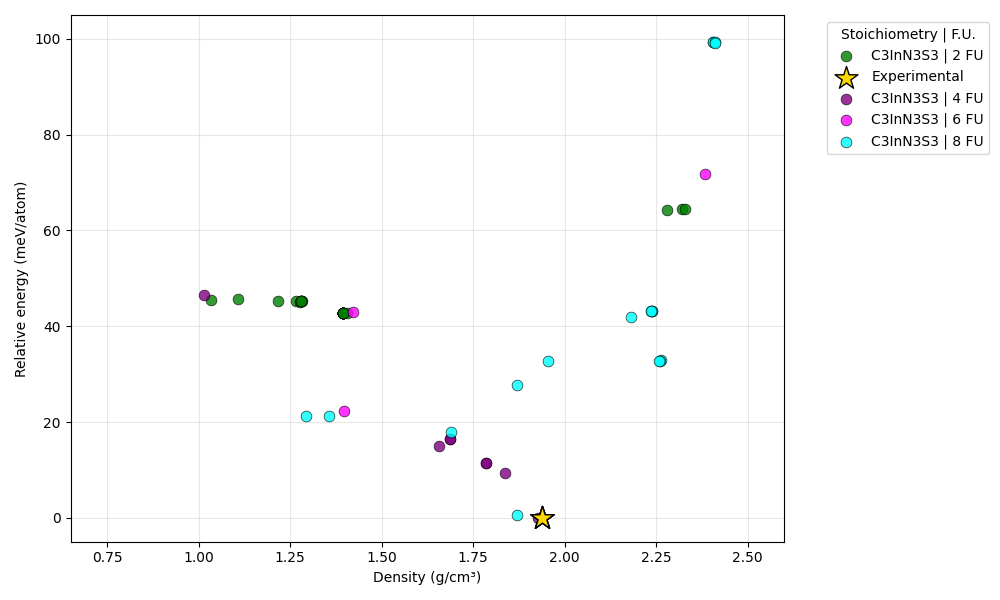

In [15]:
# Separate Jupyter cell for Energy Density Comparison Plot
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

def plot_filtered_vs_unfiltered_comparison(folder_path, config_filtered, config_unfiltered):
    """
    Create side-by-side plots comparing filtered vs unfiltered energy density data
    
    Parameters:
    -----------
    folder_path : str or Path
        Path to the folder containing .res files
    config_filtered : Config
        Configuration with filters enabled
    config_unfiltered : Config
        Configuration with filters disabled
    """
    
    folder = Path(folder_path)
    
    # Process data with filters
    print("Processing with filters enabled...")
    analyzer_filtered = RESAnalyzer(config_filtered)
    results_filtered = analyzer_filtered.process_folder(folder)
    
    # Process data without filters
    print("\nProcessing with filters disabled...")
    analyzer_unfiltered = RESAnalyzer(config_unfiltered)
    results_unfiltered = analyzer_unfiltered.process_folder(folder)
    
    if not results_filtered or not results_unfiltered:
        print("Error: Could not process data for comparison")
        return
    
    # Unpack results
    file_names_f, densities_f, energies_f, formula_units_f, stoichiometries_f = results_filtered
    file_names_u, densities_u, energies_u, formula_units_u, stoichiometries_u = results_unfiltered
    u= min(energies_u.min(), energies_f.min())
    energies_u -= u
    energies_f -= u
    # Create comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Define colors for formula units
    fu_colors = {1: 'red', 2: 'green', 3: 'blue', 4: 'purple', 
                 6: 'magenta', 8: 'cyan', 'other': 'black', 'Filtered out': 'orange'}
    
    def plot_data(ax, densities, energies, formula_units, stoichiometries, title):
        """Helper function to plot data on given axis"""
        
        # Group by stoichiometry and formula units
        unique_stoichiometries = sorted(set(stoichiometries))
        markers = ['o', 's', '^', 'D', 'P', 'v', '<', '>', '*', 'X']
        stoich_to_marker = {stoich: markers[i % len(markers)] 
                           for i, stoich in enumerate(unique_stoichiometries)}
        
        # Plot points grouped by stoichiometry and formula units
        for stoich in unique_stoichiometries:
            stoich_mask = stoichiometries == stoich
            
            for fu in sorted(set(formula_units[stoich_mask])):
                fu_mask = formula_units == fu
                combined_mask = stoich_mask & fu_mask
                
                if np.any(combined_mask):
                    color = fu_colors.get(fu, fu_colors['other'])
                    marker = stoich_to_marker[stoich]
                    
                    ax.scatter(densities[combined_mask], energies[combined_mask],
                              marker=marker, color=color, alpha=0.7, s=50,
                              label=f"{stoich} | {fu} FU")
        
        ax.set_xlabel('Density (g/cm³)')
        energy_label = 'Relative Energy (meV/atom)' if config_filtered.relative_energies_on else 'Energy per atom (meV/atom)'
        ax.set_ylabel(energy_label)
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(left=0.5, right=2.6 )  # Ensure x-axis starts at 0
        ax.set_ylim(top = 120,bottom=-30)  # Ensure y-axis starts just below 0 
        
        # Add legend outside the plot
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), 
                 bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Plot filtered data
    plot_data(ax1, densities_f, energies_f, formula_units_f, stoichiometries_f, 
              f"Filtered Data\n({len(densities_f)} points)")
    
    # Plot unfiltered data
    plot_data(ax2, densities_u, energies_u, formula_units_u, stoichiometries_u, 
              f"Unfiltered Data\n({len(densities_u)} points)")
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n📊 Comparison Statistics:")
    print(f"Unfiltered points: {len(densities_u)}")
    print(f"Filtered points: {len(densities_f)}")
    print(f"Points removed by filters: {len(densities_u) - len(densities_f)}")
    print(f"Percentage filtered out: {((len(densities_u) - len(densities_f)) / len(densities_u) * 100):.1f}%")
    


def plot_overlay_comparison(folder_path, config_filtered, config_unfiltered):
    """
    Create an overlay plot showing filtered points highlighted on top of all points
    
    Parameters:
    -----------
    folder_path : str or Path
        Path to the folder containing .res files
    config_filtered : Config
        Configuration with filters enabled
    config_unfiltered : Config
        Configuration with filters disabled
    """
    
    folder = Path(folder_path)
    
    # Process data with and without filters
    analyzer_filtered = RESAnalyzer(config_filtered)
    analyzer_unfiltered = RESAnalyzer(config_unfiltered)
    
    results_filtered = analyzer_filtered.process_folder(folder)
    results_unfiltered = analyzer_unfiltered.process_folder(folder)

    
    if not results_filtered or not results_unfiltered:
        print("Error: Could not process data for comparison")
        return
    
    # Unpack results
    file_names_f, densities_f, energies_f, formula_units_f, stoichiometries_f = results_filtered
    file_names_u, densities_u, energies_u, formula_units_u, stoichiometries_u = results_unfiltered
    u= min(energies_u.min(), energies_f.min())
    energies_u -= u
    energies_f -= u
    file_names = file_names_u.copy()
    big_energy = energies_u.copy()
    big_density = densities_u.copy()
    formula_units = np.array([''] * len(file_names_u), dtype='object')
    stoichiometries = stoichiometries_u.copy()
    for i in range(len(file_names_u)):
        if file_names_u[i] in  file_names_f:
            formula_units[i] = formula_units_u[i]
        else:
            formula_units[i] = 'Filtered out'

    analyzer_unfiltered.create_interactive_plot(
        file_names, big_energy, big_density, formula_units, stoichiometries)       

#C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3\low energy files
#C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\low_energies_from_plot
#C:\Users\Miles\Documents\morris research\computing\All ress\DFT MDB\low energy
#C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3-BJ\low energy files
folder_path = Path(r"C:\Users\Miles\Documents\morris research\computing\All ress\DFT D3-BJ\low energy files")


config_with_filters = Config()
config_with_filters.apply_cyanurate_filter = False
config_with_filters.apply_keep_octahedral = False
config_with_filters.apply_InN6_InS6_structure = False
config_with_filters.filter_folder = False
config_with_filters.convex_hull = False

config_without_filters = Config()
config_without_filters.apply_cyanurate_filter = False
config_without_filters.apply_keep_octahedral = False
config_without_filters.filter_folder = False
config_without_filters.convex_hull = False
plot_overlay_comparison(
    folder_path,
    config_with_filters,
    config_without_filters
)

In [7]:
# File count analysis by stoichiometry and formula units
# Run this cell after running your main analysis

def analyze_file_distribution(stoichiometries, formula_units):
    """Analyze and display file distribution by stoichiometry and formula units"""
    import pandas as pd
    from collections import Counter
    
    # Count files by stoichiometry
    stoich_counts = Counter(stoichiometries)
    
    # Count files by formula units
    fu_counts = Counter(formula_units)
    
    # Combined analysis: stoichiometry + formula units
    combined = [f"{stoich} ({fu} FU)" for stoich, fu in zip(stoichiometries, formula_units)]
    combined_counts = Counter(combined)
    
    print("=" * 60)
    print("FILE DISTRIBUTION ANALYSIS")
    print("=" * 60)
    
    print(f"\nTotal files processed: {len(stoichiometries)}")
    
    # Stoichiometry breakdown
    print(f"\n📊 FILES BY STOICHIOMETRY:")
    print("-" * 40)
    for stoich, count in sorted(stoich_counts.items()):
        percentage = (count / len(stoichiometries)) * 100
        print(f"{stoich:>15}: {count:>4} files ({percentage:5.1f}%)")
    
    # Formula unit breakdown
    print(f"\n📊 FILES BY FORMULA UNITS:")
    print("-" * 40)
    for fu, count in sorted(fu_counts.items()):
        percentage = (count / len(stoichiometries)) * 100
        print(f"{fu:>3} FU: {count:>4} files ({percentage:5.1f}%)")
    
    # Create summary DataFrame
    print(f"\n📋 SUMMARY TABLE:")
    print("-" * 40)
    
    # Create a cross-tabulation
    df_data = []
    for stoich, fu in zip(stoichiometries, formula_units):
        df_data.append({'Stoichiometry': stoich, 'Formula_Units': fu})
    
    df = pd.DataFrame(df_data)
    crosstab = pd.crosstab(df['Stoichiometry'], df['Formula_Units'], margins=True)
    
    print(crosstab)
    
    return stoich_counts, fu_counts, combined_counts

# Usage: Run this after your main analysis
if 'results' in globals() and results is not None:
    file_names, densities, energies, formula_units, stoichiometries = results
    analyze_file_distribution(stoichiometries, formula_units)
else:
    print("❌ No results found. Please run your main analysis first.")
    print("Make sure your main() function returns: file_names, densities, energies, formula_units, stoichiometries")

FILE DISTRIBUTION ANALYSIS

Total files processed: 5987

📊 FILES BY STOICHIOMETRY:
----------------------------------------
       C3InN3S3: 5987 files (100.0%)

📊 FILES BY FORMULA UNITS:
----------------------------------------
  1 FU:  296 files (  4.9%)
  2 FU: 1888 files ( 31.5%)
  3 FU:  203 files (  3.4%)
  4 FU: 2134 files ( 35.6%)
  6 FU:  665 files ( 11.1%)
  8 FU:  801 files ( 13.4%)

📋 SUMMARY TABLE:
----------------------------------------
Formula_Units    1     2    3     4    6    8   All
Stoichiometry                                      
C3InN3S3       296  1888  203  2134  665  801  5987
All            296  1888  203  2134  665  801  5987


In [4]:
import os
FOLDER = r"C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5"

# Dictionary to track first occurrence of each filename
seen = {}

for root, dirs, files in os.walk(FOLDER):
    for file in files:
        if file in seen:
            # Duplicate found, delete it
            dup_path = os.path.join(root, file)
            print(f"Deleting duplicate: {dup_path}")
            try:
                os.remove(dup_path)
            except Exception as e:
                print(f"Could not delete {dup_path}: {e}")
        else:
            # First time seeing this filename
            seen[file] = os.path.join(root, file)

Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\CsCdSCN3_swap.cif
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\CsCdSCN3_swap.res
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\Experimental.cif
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\Experimental.res
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\FeBiNCS6_swap.cif
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\FeBiNCS6_swap.res
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\InN6_InS6_relaxed.cif
Deleting duplicate: C:\Users\Miles\Documents\morris research\computing\All ress\DFT QC5\DFT QC5_filtered\InN6_InS6_relaxed.res
Deleting d

In [19]:
from pathlib import Path

analyzer = RESAnalyzer()

result = analyzer.parse_res_file(
    Path(r"C:\Users\Miles\Documents\morris research\computing\Experimental.res")
)

print(result)

['TITL', 'aeb_m9_2664_70_81_99_700.res', '-1', '1', '-1', '0', '0', '40', '(P2_1/c)', 'n', '-', '1']
{'density': np.float64(2.215152085685452), 'energy_per_atom': 0.0, 'formula_units': 4, 'stoichiometry': 'C3InN3S3'}


In [13]:
config = Config()
config.export_csv_summary = True
config.csv_output_name = 'low_energy_check.csv'

analyzer = RESAnalyzer(config)
low_dir = Path(tempfile.mkdtemp())
low_energy_dir = low_dir / 'low_energies_from_plot'
low_energy_dir.mkdir(exist_ok=True)

file_path = low_energy_dir / 'example.res'
file_path.write_text('TITL example 1 2 -123.456\nCELL 1 4.0 4.0 4.0 90 90 90\nSFAC In N\nIn 1 0.0000 0.0000 0.0000 1.0\nN 2 0.5000 0.5000 0.5000 1.0\nEND\n', encoding='utf-8')

analyzer.process_single_file = lambda p: ((p, 1.23, 2.34, 3, 'InN'), 0.0)
analyzer._has_cyanurate_structure = lambda atoms, neighbors: False
analyzer._has_octahedral_indium = lambda atoms, neighbors: False
analyzer._has_InN6_InS6_structure = lambda atoms, neighbors: False
analyzer._get_cached_neighbors = lambda atoms, cutoff: {'i': np.array([]), 'j': np.array([]), 'd': np.array([])}

csv_path = analyzer.export_file_summary_csv(low_dir)
print(csv_path)
print(csv_path.read_text())


C:\Users\Miles\AppData\Local\Temp\tmpcqmelhz6\low_energy_check.csv
file_name,energy_per_atom,density,formula_units,stoichiometry,has_cyanurate_structure,has_octahedral_indium,has_InN6_InS6_structure,in_low_energy_folder,filter_flags

